In [77]:
import numpy as np
import matplotlib.pylab as plt
from astropy.coordinates import SkyCoord
from astropy import units as u

### Define cluster, make a SkyCoord object to hold its position

In [78]:
cluster_name='Abell1795'

# coordinates given here http://burro.case.edu/Academics/Astr306/ClustAGN/getSDSS.html
# redshifts worked out using the SDSSanalysis notebook

if cluster_name == 'Abell2065':
    cluster_ra, cluster_dec = 230.62156, 27.70763
    cluster_redshift, redshift_low, redshift_high = 0.072, 0.06, 0.08

if cluster_name == 'Abell2063':
    cluster_ra, cluster_dec = 230.77116, 8.60859
    cluster_redshift, redshift_low, redshift_high = 0.046, 0.025, 0.55
    
if cluster_name == 'Abell1795':
    cluster_ra, cluster_dec = 207.21886, 26.59160
    #fill in this next line in based on your SDSSanalysis
    cluster_redshift, redshift_low, redshift_high = 0.063, 0.05, 0.1
    
cluster_pos=SkyCoord(cluster_ra,cluster_dec,unit='deg',frame='icrs')

### Read table of SDSS sources

In [79]:
# read SDSS datafile
from astropy.io import ascii
SDSS=ascii.read(cluster_name+'_SDSS.csv')
print('{} objects in SDSS table'.format(len(SDSS)))
print('SDSS column names: ',SDSS.colnames)

# give objects their skycoords
gal_coo=SkyCoord(SDSS['ra'],SDSS['dec'],unit='deg')
SDSS['angdist_arcsec']=gal_coo.separation(cluster_pos).arcsec

# define which ones are spectroscopically confirmed to be in the cluster
spec_conf=np.logical_and(SDSS['redshift']>redshift_low,
                         SDSS['redshift']<redshift_high)

# define which ones are projected inside 1 Mpc
from astropy.cosmology import Planck18 as cosmo
DA = cosmo.angular_diameter_distance(cluster_redshift) # in Mpc
One_Mpc_In_Arcsec = (1.0/DA.value) * 206265
print('At z={:.3f}, 1 Mpc projects to {:.1f} arcsec'.format(cluster_redshift,One_Mpc_In_Arcsec))
SDSS_inside_1Mpc = SDSS['angdist_arcsec'] < One_Mpc_In_Arcsec

25175 objects in SDSS table
SDSS column names:  ['ra', 'dec', 'type', 'u', 'g', 'r', 'i', 'z', 'modelMagErr_u', 'modelMagErr_g', 'modelMagErr_r', 'modelMagErr_i', 'modelMagErr_z', 'lnLDeV_g', 'lnLExp_g', 'redshift', 'redshiftErr']
At z=0.063, 1 Mpc projects to 797.3 arcsec


### Read or get a table of X-ray data from the Chandra source catalog

In [80]:
try:
    # if the table is already stored locally on your computer, read it from there
    CHANDRA=ascii.read(cluster_name+'_CHANDRA.csv')
    print('Read {}_CHANDRA.csv'.format(cluster_name))
    
except:
    # if there is no local table, go get the data from Vizier
    from astroquery.vizier import Vizier
    print('Querying Vizier....')
    
    # these are the columns we want to download
    # position: (RAICRS,DEICRS) in  degrees
    # position uncertainty: (r0) in arcsec
    # signal-to-noise of detection: (S/N)      
    # ACIS broad-band X-ray flux (F90b), and lower/upper limits (b_F90b,B_F90b), 
    #         all measured in erg/s/cm^2 
    # hardness of X-ray spectrum: HRhs = (Hard-Soft)/(Hard+Soft) where "Hard" is
    #         the high energy X-ray flux (2-7 keV) and "Soft" is the low energy
    #         X-ray flux (0.5-1.2 keV)   
    #         HRhs = +1 if very hard spectrum (dominated by high energy Xrays)
    #         HRhs = -1 if very soft spectrum (dominated by low energy Xrays)
    #         AGN will probably have a hardness ratio of HRhs > -0.5
    get_cols=['RAICRS','DEICRS','r0','S/N','F90b','b_F90b','B_F90b','HRhs']
    
    # and these are the filters we want to use
    # we only want point sources, not extended sources: fe=0
    # we only want sources detected in the ACIS image: F90b>0
    # we only want sources with S/N > 2
    use_filters={"fe":"=0","F90b":">0","S/N":">2"}
    
    # set up a Vizier query function
    v=Vizier(columns=get_cols,column_filters=use_filters)
    # set ROW_LIMIT=-1 which means no limit -- get all the data that satisfy the query
    v.ROW_LIMIT=-1
    
    # query Vizier for objects in a 0.5 degree radius around the position 
    # of the cluster, getting the data from catalog "IX/57" (which is the Chandra
    # source catalog). The [0] thing just means get the first data table, which
    # in our case is the only data table.
    CHANDRA=v.query_region(cluster_pos,width="0.5d",catalog="IX/57")[0]
    
    # write the downloaded data to a local file for subsequent use
    CHANDRA.write(cluster_name+'_CHANDRA.csv')  
    print('Wrote {}_CHANDRA.csv'.format(cluster_name))

print('{} objects in Chandra table'.format(len(CHANDRA)))
print('Chandra column names: ',CHANDRA.colnames)

Querying Vizier....
Wrote Abell1795_CHANDRA.csv
153 objects in Chandra table
Chandra column names:  ['RAICRS', 'DEICRS', 'r0', 'S/N', 'F90b', 'b_F90b', 'B_F90b', 'HRhs']


### Match sources from the SDSS data to the sources in the Chandra data

In [81]:
# make a sky coordinate object for all the objects in the SDSS catalog....
sdss_coord=SkyCoord(SDSS['ra'],SDSS['dec'], unit='deg', frame='icrs')

# ....and for all the objects in the Chandra catalog
chandra_coord=SkyCoord(CHANDRA['RAICRS'],CHANDRA['DEICRS'], unit='deg', frame='icrs')

# now for each chandra_coord, match it to the nearest sdss coord using sky coords (ra,dec)
# idx lists (for each chandra source) the row number in the SDSS table that contains the
#      closest match.
# d2d is the 2D separation between the sources (angle on the sky)
# d3d is the 3D separation, which is meaningless for us, since we dont have distances
idx, d2d, d3d = chandra_coord.match_to_catalog_sky(sdss_coord)

### Examine a few matches

In [82]:
# print out 1st three matches
for i in range(3):
    print('Chandra object {}:'.format(i))
    print('   X-ray positional uncertainty = {:.2f} arcsec'.format(CHANDRA['r0'][i]))
    print('   Closest match to SDSS object {}'.format(idx[i]))
    print('   Match distance = {:.2f} arcsec'.format(d2d[i].arcsec))

Chandra object 0:
   X-ray positional uncertainty = 1.52 arcsec
   Closest match to SDSS object 22774
   Match distance = 1.18 arcsec
Chandra object 1:
   X-ray positional uncertainty = 0.74 arcsec
   Closest match to SDSS object 743
   Match distance = 1.00 arcsec
Chandra object 2:
   X-ray positional uncertainty = 2.93 arcsec
   Closest match to SDSS object 1518
   Match distance = 0.73 arcsec


### Make a merged crossmatch table of the Chandra sources and the matched SDSS sources

In [83]:
# now make a merged list by "horizontally stacking" the two tables: CHANDRA and SDSS[idx]
from astropy.table import hstack
CROSSMATCHED=hstack([CHANDRA,SDSS[idx]])
# add a column that shows the separation in arcsec
CROSSMATCHED['match_sep']=d2d.arcsec
# and rename some columns so it's clear which coordinate is which
CROSSMATCHED.rename_column('RAICRS','ra_chandra')
CROSSMATCHED.rename_column('DEICRS','dec_chandra')
CROSSMATCHED.rename_column('ra','ra_SDSS')
CROSSMATCHED.rename_column('dec','dec_SDSS')

# Note: when looking at matched sources in SDSS Navigator, you ALWAYS want to 
# use the SDSS coords, not the CHANDRA coords. But you should also pay
# attention to how big the separation between the CHANDRA and SDSS coords is,
# in order to judge whether or not its a good crossmatch!

### Look at your table!

In [84]:
print('{} objects in table'.format(len(CROSSMATCHED)))
print('Column names: ',CROSSMATCHED.colnames)

#CROSSMATCHED.show_in_browser(jsviewer=True)

153 objects in table
Column names:  ['ra_chandra', 'dec_chandra', 'r0', 'S/N', 'F90b', 'b_F90b', 'B_F90b', 'HRhs', 'ra_SDSS', 'dec_SDSS', 'type', 'u', 'g', 'r', 'i', 'z', 'modelMagErr_u', 'modelMagErr_g', 'modelMagErr_r', 'modelMagErr_i', 'modelMagErr_z', 'lnLDeV_g', 'lnLExp_g', 'redshift', 'redshiftErr', 'angdist_arcsec', 'match_sep']


### Think about your X-ray source catalog

Make the following plots:

1. **log10(X-ray flux) vs X-ray S/N**
2. **X-ray position uncertainty vs log10(X-ray flux)**
3. **X-ray position uncertainty vs X-ray S/N**

*Do these plots make sense?*

Text(0.5, 1.0, '$log_{10}$(X-ray Flux) vs X-ray S/N')

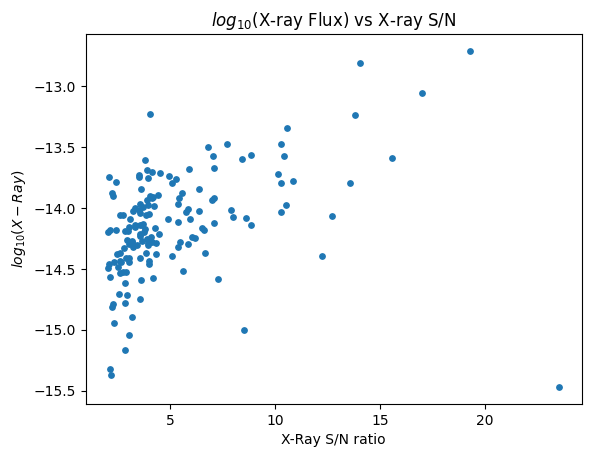

In [85]:
#log10(X-ray flux) vs X-ray S/N

plt.scatter(CROSSMATCHED['S/N'],np.log10(CROSSMATCHED['F90b']), s = 15)
plt.xlabel('X-Ray S/N ratio')
plt.ylabel(r'$log_{10}(X-Ray)$')
plt.title(r'$log_{10}$(X-ray Flux) vs X-ray S/N')

Text(0.5, 1.0, 'X-ray position uncertainty vs log10(X-ray flux)')

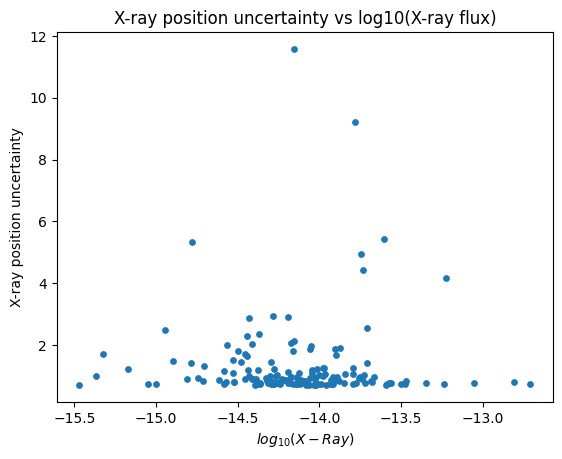

In [86]:
#X-ray position uncertainty vs log10(X-ray flux)
plt.scatter(np.log10(CROSSMATCHED['F90b']),CROSSMATCHED['r0'], s = 15)
plt.ylabel('X-ray position uncertainty')
plt.xlabel(r'$log_{10}(X-Ray)$')
plt.title('X-ray position uncertainty vs log10(X-ray flux)')

Text(0.5, 1.0, 'X-ray position uncertainty vs X-ray S/N')

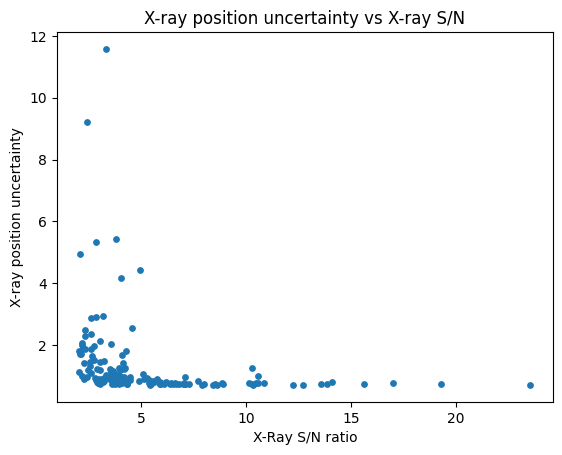

In [87]:
#X-ray position uncertainty vs X-ray S/N

plt.scatter(CROSSMATCHED['S/N'],CROSSMATCHED['r0'], s = 15)
plt.xlabel('X-Ray S/N ratio')
plt.ylabel('X-ray position uncertainty')
plt.title('X-ray position uncertainty vs X-ray S/N')

### Plot X-ray hardness vs X-ray S/N

Which objects are most likely to be AGN? Objects with X-ray hardness ('HRhs') > -0.5 have a very hard spectrum (dominated by high-energy X-rays) and are likely AGN. Softer X-ray sources are less likely to be AGN (but still could be!)

Text(0, 0.5, 'X-ray Hardness')

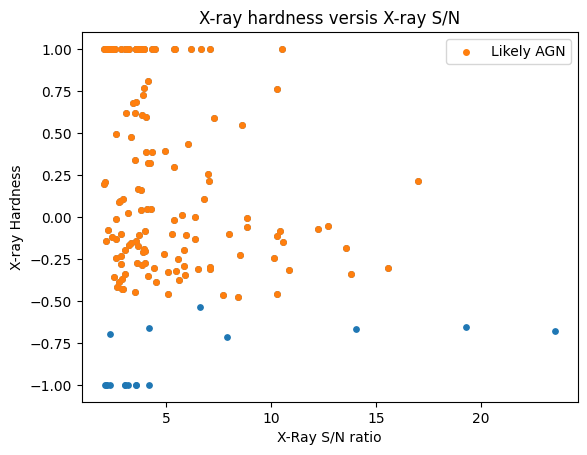

In [88]:
# your code here
likely_AGN = CROSSMATCHED['HRhs'] > -0.5
plt.scatter(CROSSMATCHED['S/N'],CROSSMATCHED['HRhs'], s = 15)
plt.scatter(CROSSMATCHED['S/N'][likely_AGN],CROSSMATCHED['HRhs'][likely_AGN], label = 'Likely AGN', s = 16)
plt.legend()
plt.title('X-ray hardness versis X-ray S/N')
plt.xlabel('X-Ray S/N ratio')
plt.ylabel('X-ray Hardness')

### Plot X-ray position uncertainty vs Chandra-SDSS separation

*Which sources look well-matched? Which do not? **Define a "well-matched criterion** and make a flag saying which sources are well-matched.*

Text(0, 0.5, 'X-ray position uncertainty')

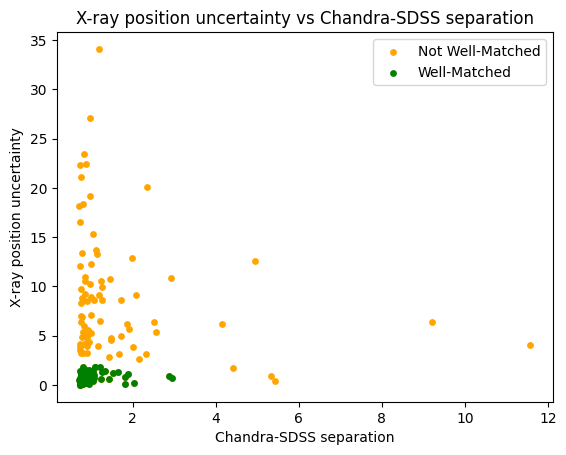

In [89]:
# your code here

well_matched = np.logical_and(CROSSMATCHED['match_sep'] < 2.5, CROSSMATCHED['r0'] < 4)

plt.scatter(CROSSMATCHED['r0'], CROSSMATCHED['match_sep'], s = 15,color = 'orange', label = 'Not Well-Matched')
plt.scatter(CROSSMATCHED['r0'][well_matched],CROSSMATCHED['match_sep'][well_matched], color = 'green', s = 15, label = 'Well-Matched')
plt.legend()
plt.title('X-ray position uncertainty vs Chandra-SDSS separation')
plt.xlabel('Chandra-SDSS separation')
plt.ylabel('X-ray position uncertainty')

### Make a cluster color magnitude diagram (CMD)

Plot g-r vs r-mag for the follwing SDSS sources, each with a different color / marker style:
1. all SDSS point sources (SDSS['type']=6) projected inside 1 Mpc of the cluster
2. all SDSS resolved sources (SDSS['type']=3) projected inside 1 Mpc of the cluster
3. all SDSS spectroscopically confirmed galaxies (i.e., with redshifts in the cluster range)
4. all SDSS sources **well-matched** to X-ray sources projected inside 1 Mpc of the cluster

*Tip: remember to set your axes appropriately: r-mag should go from 13 to 24, and g-r color should go from -1 to +2.*

Text(0.5, 1.0, 'Color Magnitude Diagram of Cluster Abell1795')

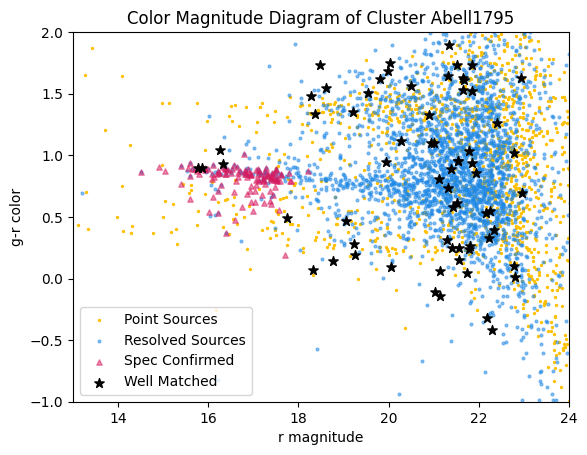

In [90]:
# your code here

g_r_color = SDSS['g'] - SDSS['r']
cross_gr = CROSSMATCHED['g'] - CROSSMATCHED['r']
z_low, z_high = 0.06,0.09
point_1MAG = np.logical_and(SDSS['type']==6,SDSS_inside_1Mpc)
resol_1MAG = np.logical_and(SDSS['type']==3,SDSS_inside_1Mpc)
spec_conf = np.logical_and(SDSS['redshift']>z_low, SDSS['redshift'] < z_high)
matched_inside_1Mpc = np.logical_and(CROSSMATCHED['angdist_arcsec'] < One_Mpc_In_Arcsec, well_matched)


plt.ylabel("g-r color")
plt.xlabel("r magnitude")

plt.scatter(SDSS['r'][point_1MAG], g_r_color[point_1MAG], color = '#FFC107', s = 2, label = 'Point Sources')
plt.scatter(SDSS['r'][resol_1MAG], g_r_color[resol_1MAG], color = '#1E88E5', alpha = 0.5, s = 4, label = 'Resolved Sources')
plt.scatter(SDSS['r'][spec_conf], g_r_color[spec_conf], marker='^', color = '#D81B60', alpha = 0.5, s = 15, label = 'Spec Confirmed')
plt.scatter(CROSSMATCHED['r'][matched_inside_1Mpc],cross_gr[matched_inside_1Mpc], marker='*', color = 'k', s = 50, label = 'Well Matched')

plt.xlim(13,24)
plt.ylim(-1,2)
plt.legend()
plt.title("Color Magnitude Diagram of Cluster {}".format(cluster_name))


### Look at your well-matched sources in Navigator

Look at a table of your **well-matched** X-ray sources projected within 1 Mpc of the cluster center. Only worry about sources brighter than r=20.5 and bluer than g-r=1.1. 

Get the **SDSS positions** of the X-ray sources that are possible cluster members, and look them up using SDSS Navigator. What do they look like, morphologically? Spectroscopically? Do they have redshifts? If so, are they in the cluster? If not, what's your best guess?

0: coord=(207.24588 26.56030), r=15.76, g-r=0.90, sep=0.15 asec, pos_unc=0.81 asec
1: coord=(207.36146 26.46189), r=15.87, g-r=0.89, sep=0.49 asec, pos_unc=0.85 asec
2: coord=(207.19064 26.55721), r=16.26, g-r=1.04, sep=0.72 asec, pos_unc=0.95 asec
3: coord=(207.18756 26.56984), r=16.33, g-r=0.93, sep=0.12 asec, pos_unc=0.75 asec
4: coord=(207.43238 26.54957), r=17.75, g-r=0.49, sep=1.55 asec, pos_unc=0.88 asec
5: coord=(207.20103 26.37201), r=18.33, g-r=0.07, sep=0.21 asec, pos_unc=0.74 asec
6: coord=(207.45795 26.56302), r=18.76, g-r=0.14, sep=1.00 asec, pos_unc=0.74 asec
7: coord=(207.42229 26.49608), r=19.07, g-r=0.47, sep=0.40 asec, pos_unc=0.92 asec
8: coord=(207.20930 26.41783), r=19.23, g-r=0.28, sep=1.00 asec, pos_unc=1.06 asec
9: coord=(207.06543 26.74512), r=19.26, g-r=0.19, sep=0.74 asec, pos_unc=0.75 asec
10: coord=(207.17889 26.70841), r=19.95, g-r=0.95, sep=1.08 asec, pos_unc=0.75 asec
11: coord=(207.38249 26.74823), r=20.05, g-r=0.09, sep=0.67 asec, pos_unc=0.83 asec


Text(0.5, 1.0, 'Well Matched X-RAY in Abell1795')

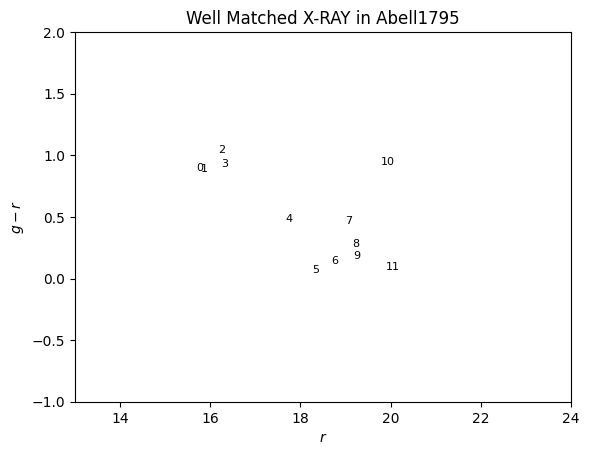

In [91]:
# pick your final sample of objects to check
# note: you may have named you flags something different....
want=np.logical_and(well_matched,matched_inside_1Mpc)
want=np.logical_and(want,CROSSMATCHED['r']<=20.5)
want=np.logical_and(want,CROSSMATCHED['g']-CROSSMATCHED['r']<=1.1)
FINAL_SAMPLE=CROSSMATCHED[want]

# sort it in r-band magnitude (brightest ones first)
FINAL_SAMPLE.sort(['r'])
#FINAL_SAMPLE.show_in_browser(jsviewer=True)

for i in range(len(FINAL_SAMPLE)):
        ra, dec = FINAL_SAMPLE['ra_SDSS'][i],FINAL_SAMPLE['dec_SDSS'][i]
        rmag, grcolor = FINAL_SAMPLE['r'][i],FINAL_SAMPLE['g'][i]-FINAL_SAMPLE['r'][i]
        match_sep,r0 = FINAL_SAMPLE['match_sep'][i],FINAL_SAMPLE['r0'][i]
        plt.text(rmag,grcolor,i,ha='center',va='center',fontsize=8)
        print('{}: coord=({:.5f} {:.5f}), r={:.2f}, g-r={:.2f}, '.format(i,ra,dec,rmag,grcolor),end='')
        print('sep={:.2f} asec, pos_unc={:.2f} asec'.format(match_sep,r0))
        
plt.xlabel('$r$')
plt.ylabel('$g-r$')
plt.xlim([13,24])
plt.ylim([-1,2])
plt.title("Well Matched X-RAY in {}".format(cluster_name))